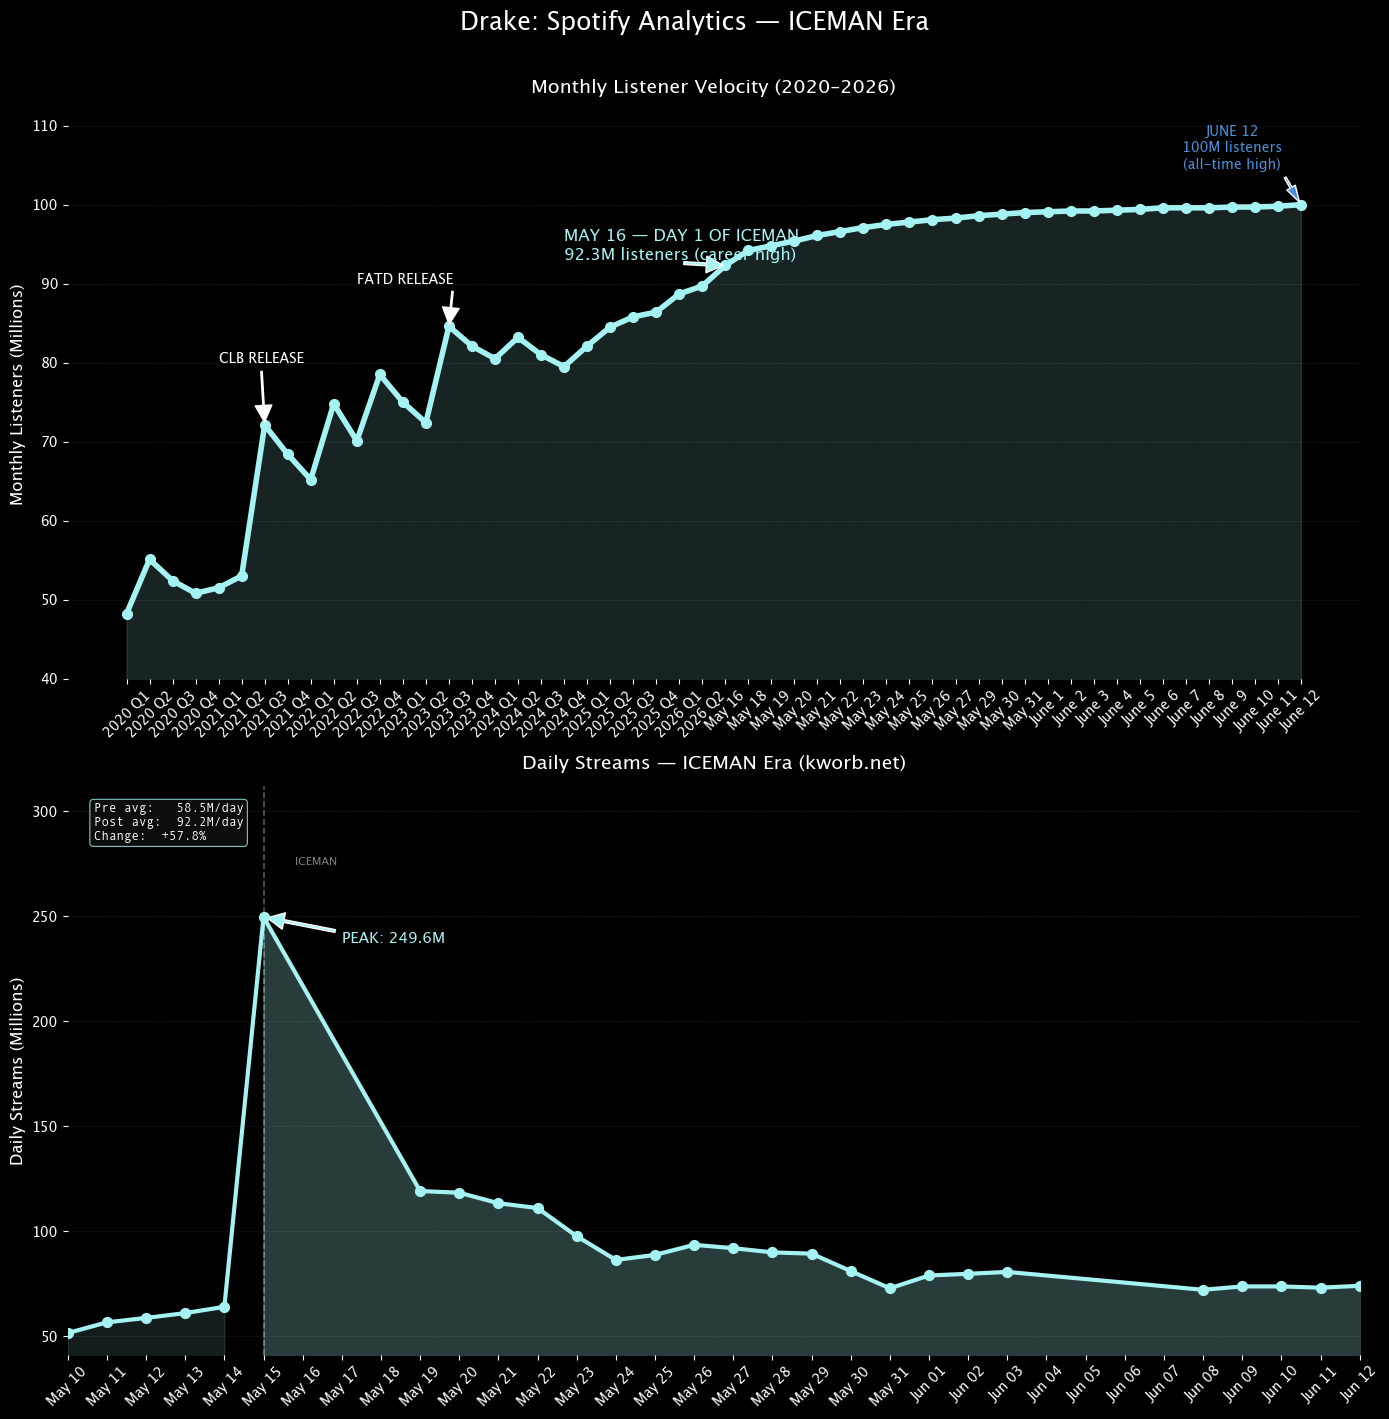

Saved.


In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

plt.style.use('dark_background')
ICEMAN_BLUE = '#A5F2F3'
MILESTONE_BLUE = '#4A90D9'

# ── DATA ──────────────────────────────────────────────────────────────────────
# open.spotify.com/artist/3TVXtAsR1Inumwj472S9r4 → monthly listeners
listener_data = {
    'Quarter': ['2020 Q1','2020 Q2','2020 Q3','2020 Q4',
                '2021 Q1','2021 Q2','2021 Q3','2021 Q4',
                '2022 Q1','2022 Q2','2022 Q3','2022 Q4',
                '2023 Q1','2023 Q2','2023 Q3','2023 Q4',
                '2024 Q1','2024 Q2','2024 Q3','2024 Q4',
                '2025 Q1','2025 Q2','2025 Q3','2025 Q4',
                '2026 Q1','2026 Q2','May 16','May 18','May 19','May 20','May 21','May 22','May 23','May 24','May 25','May 26','May 27','May 29','May 30','May 31', 'June 1', 'June 2', 'June 3', 'June 4', 'June 5', 'June 6','June 7', 'June 8', 'June 9', 'June 10', 'June 11', 'June 12'],
    'Listeners': [48.2,55.1,52.4,50.8,
                  51.5,53.0,72.1,68.4,
                  65.2,74.8,70.1,78.5,
                  75.0,72.4,84.6,82.1,
                  80.5,83.2,81.0,79.5,
                  82.1,84.5,85.8,86.4,
                  88.7,89.7,92.3,94.2,94.8,95.4,96.1,96.6,97.1,97.5,97.8,98.1,98.3,98.6,98.8,99, 99.1, 99.2, 99.2, 99.3, 99.4, 99.6, 99.6, 99.6, 99.7, 99.7, 99.8, 100]
}

# kworb.net/spotify/artists.html → "Daily" column, logged each morning in millions
# Dates and Streams must have the same length — use None for unconfirmed days
stream_data = {
    'Date':    ['2026-05-10','2026-05-11','2026-05-12','2026-05-13','2026-05-14',
                '2026-05-15','2026-05-16','2026-05-17','2026-05-18','2026-05-19',
                '2026-05-20','2026-05-21','2026-05-22','2026-05-23','2026-05-24','2026-05-25', '2026-05-26', '2026-05-27','2026-05-28', '2026-05-29', '2026-05-30', '2026-05-31', '2026-06-01', '2026-06-02', '2026-06-03', '2026-06-08', '2026-06-09', '2026-06-10', '2026-06-11', '2026-06-12', '2026-06-13', '2026-06-14', '2026-06-15'],
    'Streams': [51.6, 56.7, 58.8, 61.1, 64.1,
                249.6, None, None, None,
                119.2, 118.4, 113.4, 111.1, 97.7, 86.4, 88.8, 93.6, 92, 90, 89.4, 81.1, 72.9, 79, 79.8, 80.7, 72.2, 73.8, 73.8, 73.2, 74.1, 69.2, 61.2, 65.5]
}

# ── CONFIG ────────────────────────────────────────────────────────────────────
RELEASE_DATE = pd.Timestamp('2026-05-15')
X_START      = pd.Timestamp('2026-05-10')
X_END        = pd.Timestamp('2026-06-12')
has_streams  = bool(stream_data['Date'])

if has_streams:
    df_s = pd.DataFrame(stream_data)
    df_s['Date'] = pd.to_datetime(df_s['Date'])
    df_s = df_s.sort_values('Date').reset_index(drop=True)
    df_s = df_s.dropna(subset=['Streams'])
    pre  = df_s[df_s['Date'] <  RELEASE_DATE]
    post = df_s[df_s['Date'] >= RELEASE_DATE]

# ── HELPERS ───────────────────────────────────────────────────────────────────
def clean_ax(ax):
    ax.grid(axis='y', linestyle='--', alpha=0.1)
    ax.grid(axis='x', visible=False)
    ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

def set_date_axis(ax):
    ax.set_xlim(X_START, X_END)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.tick_params(axis='x', rotation=45)

def add_release_line(ax):
    ax.axvline(RELEASE_DATE, color='white', linewidth=1.2, linestyle='--', alpha=0.35)
    ax.annotate('ICEMAN', xy=(RELEASE_DATE, ax.get_ylim()[1] * 0.88),
                xytext=(RELEASE_DATE + pd.Timedelta(days=0.8), ax.get_ylim()[1] * 0.88),
                fontsize=8, color='white', alpha=0.5)

def empty_chart(ax, msg):
    ax.text(0.5, 0.5, msg, transform=ax.transAxes, ha='center', va='center',
            fontsize=13, color='white', alpha=0.3,
            bbox=dict(boxstyle='round', facecolor='none', edgecolor='white', alpha=0.15))
    set_date_axis(ax)

# ── LAYOUT ────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 14))
fig.suptitle("Drake: Spotify Analytics — ICEMAN Era", fontsize=18, fontweight='bold', y=1.01)

# ── CHART 1: MONTHLY LISTENERS ────────────────────────────────────────────────
df_l = pd.DataFrame(listener_data)
ax1.plot(df_l['Quarter'], df_l['Listeners'], color=ICEMAN_BLUE, linewidth=4, marker='o', markersize=7)
ax1.fill_between(df_l['Quarter'], df_l['Listeners'], color=ICEMAN_BLUE, alpha=0.15)

for text, xy, xytext in [
    ('CLB RELEASE',  ('2021 Q3', 72.1), ('2021 Q1', 80)),
    ('FATD RELEASE', ('2023 Q3', 84.6), ('2022 Q3', 90)),
]:
    ax1.annotate(text, xy=xy, xytext=xytext, fontsize=10,
                 arrowprops=dict(facecolor='white', shrink=0.05, width=1))

ax1.annotate('MAY 16 — DAY 1 OF ICEMAN\n92.3M listeners (career high)',
             xy=('May 16', 92.3), xytext=('2024 Q4', 93),
             arrowprops=dict(facecolor=ICEMAN_BLUE, shrink=0.05, width=2),
             fontsize=12, fontweight='bold', color=ICEMAN_BLUE)

ax1.annotate('JUNE 12\n100M listeners\n(all-time high)',
             xy=('June 12', 100),
             xytext=('June 9', 104.5),
             arrowprops=dict(facecolor=MILESTONE_BLUE, shrink=0.08, width=1.5, headwidth=7),
             fontsize=10, fontweight='bold', color=MILESTONE_BLUE, ha='center')

ax1.set_title("Monthly Listener Velocity (2020–2026)", fontsize=14, pad=12)
ax1.set_ylabel("Monthly Listeners (Millions)", fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.set_ylim(40, 112)
clean_ax(ax1)

# ── CHART 2: DAILY STREAMS ────────────────────────────────────────────────────
if has_streams and not df_s.empty:
    ax2.plot(df_s['Date'], df_s['Streams'], color=ICEMAN_BLUE, linewidth=3, zorder=2)

    if not pre.empty:
        ax2.fill_between(pre['Date'], pre['Streams'], color=ICEMAN_BLUE, alpha=0.12)
        ax2.scatter(pre['Date'], pre['Streams'], color=ICEMAN_BLUE, s=50, zorder=5)

    if not post.empty:
        ax2.fill_between(post['Date'], post['Streams'], color=ICEMAN_BLUE, alpha=0.25)
        ax2.scatter(post['Date'], post['Streams'], color=ICEMAN_BLUE, s=50, zorder=5)

        peak = post.loc[post['Streams'].idxmax()]
        ax2.annotate(f"PEAK: {peak['Streams']:.1f}M", xy=(peak['Date'], peak['Streams']),
                     xytext=(peak['Date'] + pd.Timedelta(days=2), peak['Streams'] * 0.95),
                     arrowprops=dict(facecolor=ICEMAN_BLUE, shrink=0.05, width=2),
                     fontsize=11, fontweight='bold', color=ICEMAN_BLUE)

    pre_avg  = pre['Streams'].mean()  if not pre.empty  else 0
    post_avg = post['Streams'].mean() if not post.empty else 0
    if pre_avg and post_avg:
        pct = (post_avg - pre_avg) / pre_avg * 100
        ax2.text(0.02, 0.97, f"Pre avg:   {pre_avg:.1f}M/day\nPost avg:  {post_avg:.1f}M/day\nChange:  {pct:+.1f}%",
                 transform=ax2.transAxes, fontsize=9, verticalalignment='top',
                 family='monospace', color='white',
                 bbox=dict(boxstyle='round', facecolor='#111', alpha=0.8,
                           edgecolor=ICEMAN_BLUE, linewidth=0.8))

    y_min = df_s['Streams'].min() * 0.8
    y_max = df_s['Streams'].max() * 1.25
    ax2.set_ylim(y_min, y_max)
    add_release_line(ax2)
    set_date_axis(ax2)
else:
    empty_chart(ax2, 'No stream data yet\nAdd dates + streams to stream_data above')
    ax2.set_ylim(0, 60)

ax2.set_title("Daily Streams — ICEMAN Era (kworb.net)", fontsize=14, pad=12)
ax2.set_ylabel("Daily Streams (Millions)", fontsize=12)
clean_ax(ax2)

plt.tight_layout()
plt.savefig('drake_iceman_analytics.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
plt.close()
print("Saved.")